In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
class Value:
    def __init__(self,data,label='',_children=(),_op=''):
        self.data=data
        self._prev=set(_children)
        self.label=label
        self.grad=0.0
        self._op=_op
        self.backward=lambda:None
        
    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"
    def __add__(self,other):
        out=Value(self.data+other.data,_children=(self,other),_op='+')
        def _backward():
            self.grad+=out.grad*1.0
            other.grad+=out.grad*1.0
        out.backward=_backward
        return out
    def __mul__(self,other):
        
        out=Value(self.data*other.data,_children=(self,other),_op='*')
        def _backward():
            self.grad+=out.grad*other.data
            other.grad+=out.grad*self.data
        out.backward=_backward
        return out
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,_children=(self,),_op='tanh')
        def _backward():
            self.grad+=out.grad*(1-t**2)
        out.backward=_backward
        return out
    

In [3]:
a=Value(3.0,'a')
b=Value(-2.0,'b')
c=a+b;c.label='c'


In [4]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


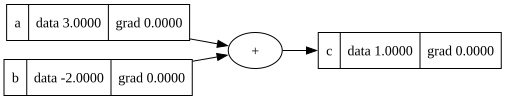

In [5]:
draw_dot(c)

In [ ]:
#接下来是反向传递的示例，看看能不能正常运行backward
    